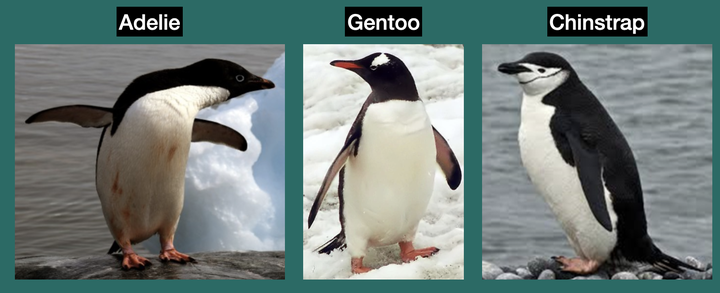
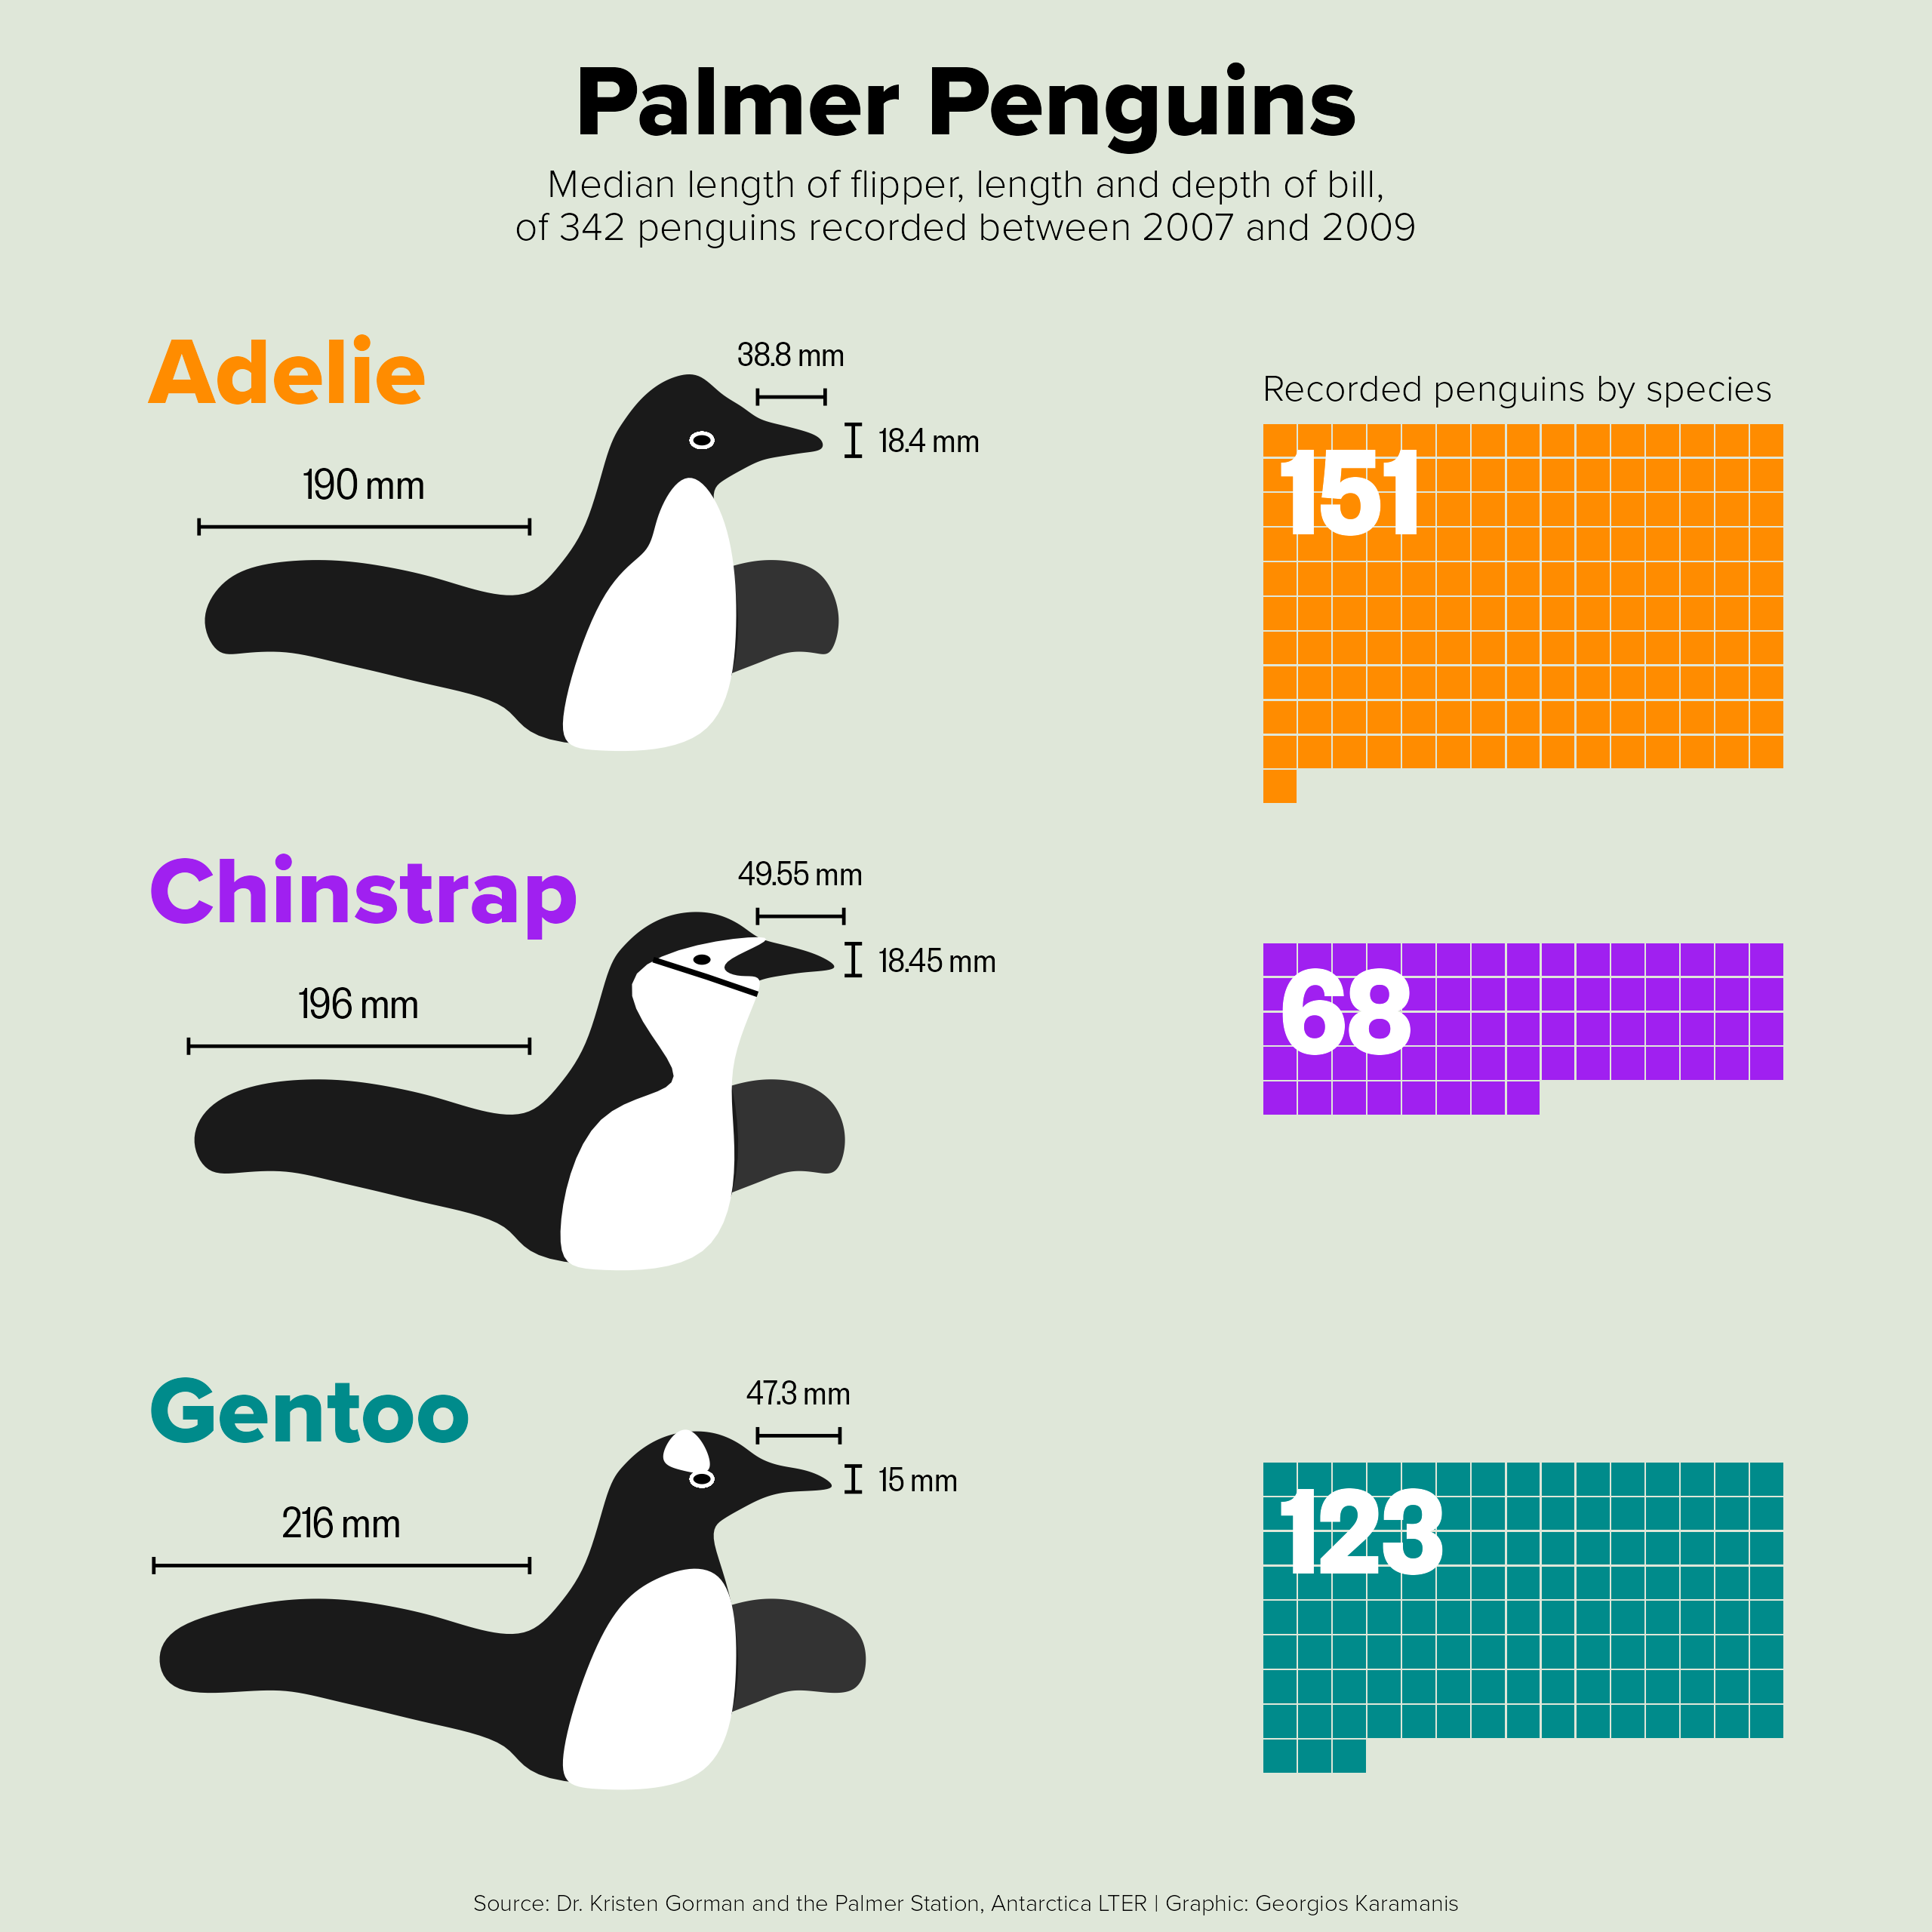
![alt text](image-1.png)
![alt text](image.png)

# 🌱 Seaborn 샘플 데이터 PCA 전처리 예제

Palmer Penguins dataset

이 예제는 Seaborn의 펭귄 데이터를 활용하여
**PCA 전처리 → 표준화 → 차원 축소 → 시각화** 전체 흐름을 학습하는 실습이다.

---

# 📦 1️⃣ 라이브러리 로드

```python
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
```

---

# 🐧 2️⃣ 데이터 로드

```python
df = sns.load_dataset("penguins")
df.head()
```

---

# ⚠️ 3️⃣ 결측값 처리

PCA는 결측값을 허용하지 않기 때문에 반드시 제거해야 한다.

```python
df = df.dropna()
```

---

# 🎯 4️⃣ 수치형 feature 선택

```python
features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

X = df[features]
```

---

# ⚙️ 5️⃣ 표준화 (중요 전처리 단계)

PCA는 분산 기반 알고리즘이므로
스케일 차이를 제거해야 한다.

```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
```

---

# 🔥 6️⃣ PCA 적용 (2차원 축소)

```python
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
```

---

# 📊 7️⃣ 설명 분산 비율 확인

```python
print("설명 분산 비율:", pca.explained_variance_ratio_)
print("누적 설명 분산:", np.cumsum(pca.explained_variance_ratio_))
```

---

# 🎨 8️⃣ PCA 결과 시각화

```python
plt.figure(figsize=(7,5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=pd.Categorical(df["species"]).codes
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Result - Penguins Dataset")
plt.show()
```

---

# 🧠 핵심 전처리 흐름

## ✔️ PCA 전체 파이프라인

1. 결측값 제거
2. 숫자형 feature 선택
3. 표준화 (StandardScaler)
4. PCA 적용
5. 결과 시각화

---

# ⚠️ 전처리를 반드시 해야 하는 이유

## ❌ 표준화 없이 PCA 수행하면

* body_mass_g (큰 값)가 PCA를 지배
* 결과 왜곡 발생

---

## ✅ 표준화 후 PCA

* 모든 feature가 동일한 기준으로 반영
* 실제 데이터 구조 반영 가능

---

# 🚀 한 줄 정리

👉 **Seaborn penguins 데이터는 PCA 전처리(결측 처리 → 표준화 → 차원 축소 → 시각화) 전체 흐름을 실습하기에 가장 적합한 데이터셋이다.**


# 🌱 PCA 예제: 사람 신체 데이터 분석 (몸무게 포함)

이 예제는 사람의 신체 데이터를 이용하여
**PCA 전처리 → 차원 축소 → 해석**까지 이해하는 실습이다.

---

# 📊 1️⃣ 데이터 생성

```python id="pca_body_01"
import pandas as pd

data = {
    "height": [160, 165, 170, 175, 180, 185],
    "weight": [55, 60, 65, 70, 75, 80],
    "arm_length": [50, 52, 54, 56, 58, 60],
    "leg_length": [80, 82, 84, 86, 88, 90]
}

df = pd.DataFrame(data)
print(df)
```

---

# ⚙️ 2️⃣ 표준화 (PCA 필수 전처리)

```python id="pca_body_02"
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
```

---

# 🔥 3️⃣ PCA 적용

```python id="pca_body_03"
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
```

---

# 📊 4️⃣ 설명 분산 비율 확인

```python id="pca_body_04"
print("설명 분산 비율:", pca.explained_variance_ratio_)
```

---

# 🧠 5️⃣ 결과 해석

## ✔️ PC1 (첫 번째 주성분)

* height
* weight
* arm_length
* leg_length

👉 모두 같은 방향으로 영향

> 🌟 의미: **전체 신체 크기 (Body Size)**

---

## ✔️ PC2 (두 번째 주성분)

* 일부는 + 영향
* 일부는 - 영향

👉 팔/다리/몸무게 비율 차이

> 🌟 의미: **체형 구조 (Body Shape)**

---

# 📐 6️⃣ 주성분 방향 확인

```python id="pca_body_05"
print("주성분 방향:")
print(pca.components_)
```

---

# 📊 7️⃣ PCA 시각화

```python id="pca_body_06"
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1])

plt.xlabel("PC1 (Body Size)")
plt.ylabel("PC2 (Body Shape)")
plt.title("PCA Result: Human Body Data")
plt.show()
```

---

# 🧠 핵심 해석

## ✔️ PC1

👉 사람의 “전체 크기”

* 키 큼
* 몸무게 큼
* 팔다리 길이 큼

---

## ✔️ PC2

👉 사람의 “비율 차이”

* 상체 vs 하체
* 팔 vs 다리 비율

---

# ⚠️ 중요한 전처리 포인트

## ❌ 표준화 안 하면

* weight 값이 PCA를 지배
* 결과 왜곡 발생

---

## ✅ 표준화 하면

* 모든 feature 균등 반영
* 진짜 구조 학습 가능

---

# 🚀 한 줄 정리

👉 **이 PCA 예제는 사람의 신체 데이터를 “전체 크기(PC1) + 체형 비율(PC2)”로 압축하는 과정을 보여준다.**


In [1]:
# 시각화 라이브러리
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 처리
import pandas as pd
import numpy as np

# 펭귄 데이터 불러오기
df = sns.load_dataset("penguins")


# 상위 5개 출력
print(df.head())

# df.to_excel("펭귄.xlsx")

# species → 펭귄 종류 (목표 확인용)
# island → 서식 섬
# bill_length_mm → 부리 길이
# bill_depth_mm → 부리 깊이
# flipper_length_mm → 날개 길이
# body_mass_g → 몸무게
# sex → 성별

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


In [2]:
# 데이터 크기
print(df.shape)
# 컬럼 정보
print(df.info())
# 기초 통계량
print(df.describe())

(344, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000

In [3]:
# 3단계 — 결측치 확인
print(df.isnull().sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [4]:
# 결측치 제거
# 수치형만 보기 위해 제거해 버림
df = df.dropna()
print(df.shape)


(333, 7)


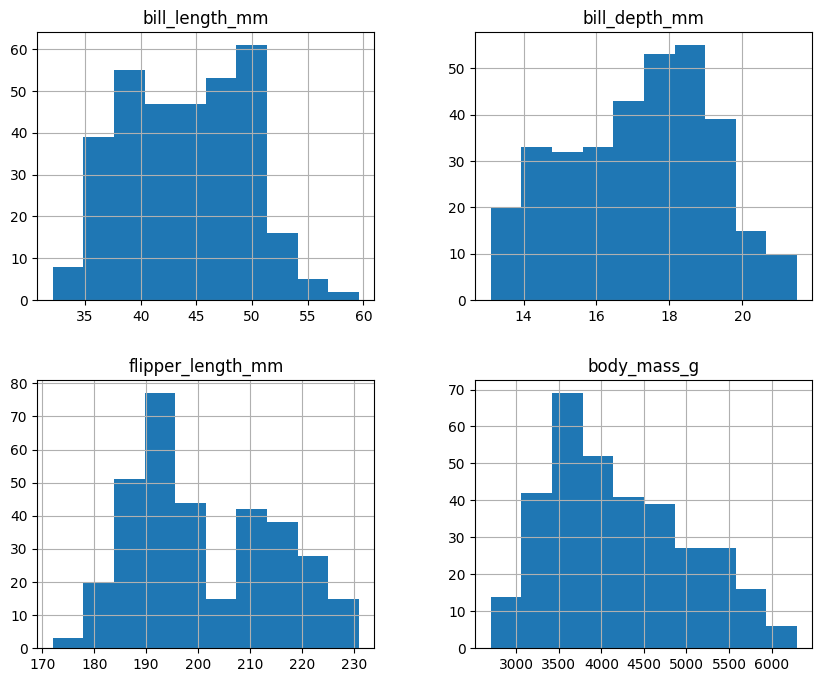

In [5]:
# 수치 컬럼만 선택
num_cols = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

# 히스토그램
df[num_cols].hist(
    figsize=(10,8)
)

plt.show()

                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.228626           0.653096   
bill_depth_mm           -0.228626       1.000000          -0.577792   
flipper_length_mm        0.653096      -0.577792           1.000000   
body_mass_g              0.589451      -0.472016           0.872979   

                   body_mass_g  
bill_length_mm        0.589451  
bill_depth_mm        -0.472016  
flipper_length_mm     0.872979  
body_mass_g           1.000000  


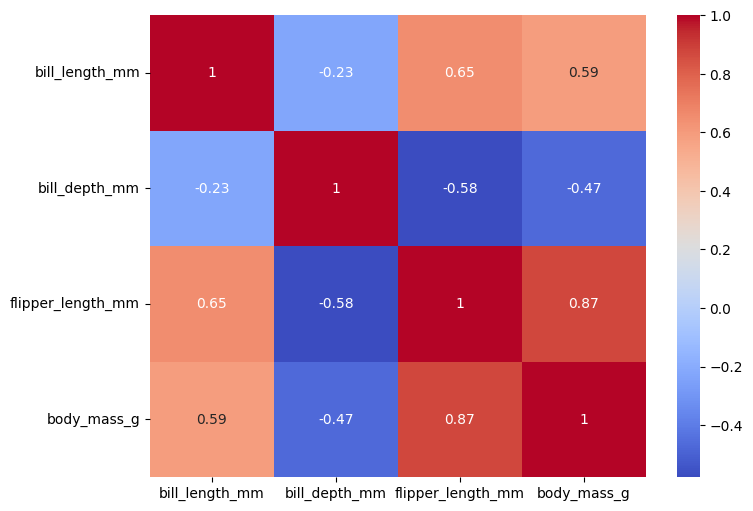

In [6]:
# 상관계수 계산
corr = df[num_cols].corr()

print(corr)
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [7]:
# flipper_length ↔ body_mass
# 0.87
# → 날개가 길수록 무게가 증가


In [8]:
# 6단계 — PCA 준비 (표준화)
# PCA는 스케일에 매우 민감

from sklearn.preprocessing import StandardScaler

# 입력 데이터 선택
X = df[num_cols]


# 표준화 객체
scaler = StandardScaler()


# 평균0 표준편차1
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.89604189  0.7807321  -1.42675157 -0.56847478]
 [-0.82278787  0.11958397 -1.06947358 -0.50628618]
 [-0.67627982  0.42472926 -0.42637319 -1.1903608 ]
 [-1.33556603  1.0858774  -0.56928439 -0.94160639]
 [-0.85941488  1.74702554 -0.78365118 -0.69285199]]


In [9]:
# PCA 수행
from sklearn.decomposition import PCA

# 2차원 축소
pca = PCA(
    n_components=2
)

# PCA 적용
X_pca = pca.fit_transform(
    X_scaled
)

print(X_pca[:5])

[[-1.85359302  0.03206938]
 [-1.31625406 -0.44352677]
 [-1.37660509 -0.16123048]
 [-1.88528838 -0.01235124]
 [-1.91998074  0.81759813]]


In [ ]:
print(pca.explained_variance_ratio_)
# PC1 → 69%
# PC2 → 20%
# 총 89% 설명

# 원본 4개 특징을
# ↓
# 2개만 써도
# ↓
# 89% 정보 유지

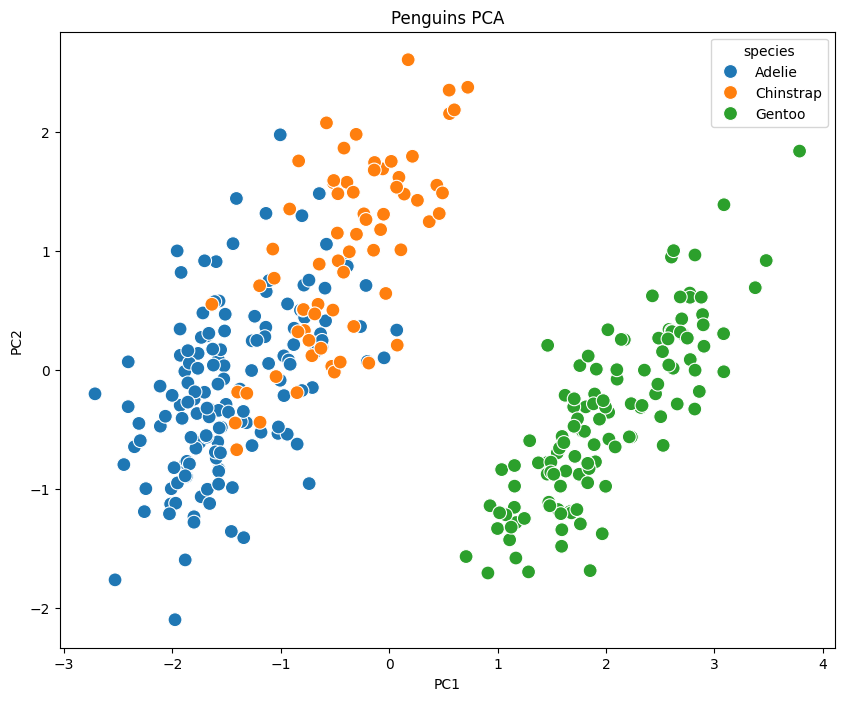

In [10]:
# PCA 결과 시각화

# 데이터프레임 생성
pca_df = pd.DataFrame(
    X_pca,
    columns=[
        "PC1",
        "PC2"
    ]
)


# 종 정보 추가
pca_df["species"] = df["species"].values


# 그래프
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="species",
    s=100
)

plt.title("Penguins PCA")

plt.show()

In [ ]:
loading = pd.DataFrame(
    pca.components_,
    columns=num_cols,
    index=["PC1","PC2"]
)

print(loading)

# PC1 = 몸무게 + 날개길이
# 중심 축
# PC2 = 부리 특징

     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
PC1        0.453753      -0.399047           0.576825     0.549675
PC2        0.600195       0.796170           0.005788     0.076464


In [ ]:
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 데이터
df = sns.load_dataset("penguins")
df = df.dropna()


X = df[["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]]
y = df["species"]


# 분리
X_train,X_test,y_train,y_test=(
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)


# 표준화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

result=[]

# PCA 개수 탐색
for n in range(1,5):
    pca=PCA(n_components=n)

    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    model=(LogisticRegression(max_iter=1000))

    model.fit(X_train_pca,y_train)

    pred=(model.predict(X_test_pca))
    score=(accuracy_score(y_test,pred))

    result.append([n,score,pca.explained_variance_ratio_.sum()])


result=pd.DataFrame(
    result,
    columns=[
        "PCA",
        "Accuracy",
        "Variance"
    ]
)

print(result)

   PCA  Accuracy  Variance
0    1  0.910448  0.691595
1    2  0.940299  0.887236
2    3  1.000000  0.972415
3    4  1.000000  1.000000


# 성능 비교 = 파이프 라인 쓰기

In [ ]:
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (GridSearchCV,train_test_split)


# 데이터
df = sns.load_dataset("penguins").dropna()

X = df[["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]]
y = df["species"]

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42)    


# 파이프라인
pipe = Pipeline([
    ("scaler",StandardScaler()),
    ("pca",PCA()),
    ("knn",KNeighborsClassifier())
])


# 탐색 공간
param_grid = {
    "pca__n_components":[1,2,3,4],
    "knn__n_neighbors":[3,5,7,9]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5
)

grid.fit(X_train,y_train)

print("최적:")
print(grid.best_params_)
print(grid.best_score_)
print(grid.score(X_test,y_test))

최적:
{'knn__n_neighbors': 5, 'pca__n_components': 4}
0.9919183673469387
0.9880952380952381
